In [1]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, core_promoter
# ============================================================
variant_class = 'missense'
exclude_clinvar = False  # Independent toggle: exclude ClinVar-annotated variants
only_clinvar = False

# selected_categories = ['plof', 'missense', 'splicing', 'conservation', 'regulatory'] # Gene Body
selected_categories = ['missense', 'genetic_diversity', 'conservation'] # missense
# selected_categories = ['protein_domains'] # protein domains
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/config_variant_classes.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Exclude ClinVar: {exclude_clinvar}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_pheno.yaml" 

with open(config_path) as f:
    config = yaml.safe_load(f)
    
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

Variant class: missense
  Filters: ["pl.col('consequence_missense_variant') == True"]
  Exclude ClinVar: False


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1


In [3]:
anno_config_df.filter(pl.col('category')=='regulatory')

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""regulatory""","""promoterai_abs""","""#1F77B4""","""PromoterAI abs""",1
"""regulatory""","""promoterai_under""","""#1F77B4""","""PromoterAI""",-1
"""regulatory""","""abexp_min""","""#1F77B4""","""AbExp min""",-1
"""regulatory""","""fz_all_min""","""#1F77B4""","""Flashzoi min across RNA (all)""",-1
"""regulatory""","""fz_gtex_min""","""#1F77B4""","""Flashzoi min across RNA (GTEx)""",-1


In [4]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

# CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
CORR_FILE = "regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per_correlations.parquet"
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per_correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000084674""","""ldl_direct_int""",2.2543e-301,-0.12678,0.12678,-1.0
"""ENSG00000167701""","""alanine_aminotransferase_int""",1.2234e-144,-0.106424,0.106424,-1.0
"""ENSG00000105610""","""mean_corpuscular_haemoglobin_i…",9.8993e-24,-0.100921,0.100921,-1.0
"""ENSG00000141505""","""alkaline_phosphatase_int""",8.4146e-35,0.089171,0.089171,1.0
"""ENSG00000101162""","""platelet_distribution_width_in…",1.5335e-83,0.08869,0.08869,1.0
…,…,…,…,…,…
"""ENSG00000115977""","""sitting_height_int""",0.021257,-0.001496,0.001496,-1.0
"""ENSG00000119574""","""standing_height_int""",0.025535,-0.001317,0.001317,-1.0
"""ENSG00000115325""","""platelet_distribution_width_in…",0.01277,-0.001204,0.001204,-1.0


In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Build dynamic filters from variant_class.yaml
if vc_filters is not None:
    _dynamic_filters = [eval(f) for f in vc_filters]
else:
    _dynamic_filters = []

anno = (
    anno
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
    .with_columns(
        promoterai_under = pl.col('promoterai'),
        promoterai_abs = pl.col('promoterai').abs(),

        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_full_lip_priority']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
)

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_44695/298273397.py:41: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_44695/298273397.py:50: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


region,priphylop,cadd_raw,verphylop,mamphylop,bayes_del,esm1b_llr,am_pathogenicity,zooverphylop,clinpred_score,cpt1_llr,polyphen,esmscoremissense,gpn_score,id,revel_score,zoopriphylop
str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,f32,f32
"""ENSG00000169174""",0.321,1.433654,3.942,1.399,-0.466288,0.0,0.1214,0.648,0.133098,0.0,0.018,-3.493,-3.65,"""chr1:55063472:T:C""",0.058,0.628
"""ENSG00000159307""",0.469,2.591084,3.941,1.805,-0.540699,-6.432,0.0852,3.649,0.551985,0.121972,0.014,-5.821,-4.9,"""chr22:43258222:T:C""",0.067,0.999
"""ENSG00000162692""",0.595,2.219246,2.519,2.982,-0.378917,-2.519,0.2021,3.482,0.673255,0.102354,0.071,-2.005,-5.35,"""chr1:100723217:G:T""",0.104,0.937
"""ENSG00000196235""",0.595,5.277146,8.82,4.494,0.021352,-5.819,0.8453,8.787,0.963567,0.146373,0.998,-4.157,-10.89,"""chr19:39473487:G:A""",0.52,0.998
"""ENSG00000145703""",-0.508,0.397732,0.663,-0.992,-0.709861,-2.956,0.0625,-2.114,0.034818,0.034421,0.0,-2.699,0.11,"""chr5:76693399:A:G""",0.137,0.971
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000163808""",0.467,1.747462,0.115,1.297,-0.544942,-4.066,0.1068,0.708,0.082661,0.115931,0.003,-3.692,-4.78,"""chr3:44841208:A:C""",0.071,0.999
"""ENSG00000144749""",0.418,5.213512,7.518,2.907,0.309983,-9.881,0.8301,8.903,0.999639,0.315277,1.0,-5.737,-11.28,"""chr3:66383040:C:G""",0.71,0.986
"""ENSG00000061987""",0.418,5.366776,7.518,2.907,0.096229,-10.261,0.9092,8.872,0.98067,0.207261,0.914,-3.858,-8.94,"""chr12:62501682:C:T""",0.559,0.999


In [6]:
# # Load fillna annotations
# anno_fillna = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")
# fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

# anno_fillna_melted = (
#     anno_fillna
#     .select(['id', 'region'] + list(fillna_cols))
#     .join(
#         anno.select(['id', 'region']).lazy(), 
#         on=['id', 'region'], 
#         how='semi'
#     )
#     .unpivot(
#         index=["id", "region"],
#         on=list(fillna_cols),
#         variable_name="annotation",
#         value_name="annotation_is_na"
#     )
#     .filter(
#         pl.col('annotation_is_na') == 1
#     )
#     .with_columns(
#         annotation = pl.col('annotation').str.replace('_is_na$', '')
#     )
#     # .collect(engine='streaming')
# )

melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
        
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    
    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr1:55063472:T:C""","""ENSG00000169174""","""priphylop""",0.321
"""chr22:43258222:T:C""","""ENSG00000159307""","""priphylop""",0.469
"""chr1:100723217:G:T""","""ENSG00000162692""","""priphylop""",0.595
"""chr19:39473487:G:A""","""ENSG00000196235""","""priphylop""",0.595
"""chr5:76693399:A:G""","""ENSG00000145703""","""priphylop""",-0.508
…,…,…,…
"""chr3:44841208:A:C""","""ENSG00000163808""","""zoopriphylop""",0.999
"""chr3:66383040:C:G""","""ENSG00000144749""","""zoopriphylop""",0.986
"""chr12:62501682:C:T""","""ENSG00000061987""","""zoopriphylop""",0.999


In [7]:
melted_anno['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""priphylop""",405054
"""clinpred_score""",405054
"""cpt1_llr""",405054
"""cadd_raw""",405054
"""esmscoremissense""",405054
…,…
"""esm1b_llr""",405054
"""am_pathogenicity""",405054
"""revel_score""",405054


In [8]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)


Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


In [9]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Build the main lazy query plan
# Join order: appv → id_region (adds region) → gene_trait_df (filter early) → melted_anno (annotation scores)
final_lazy_plan = (
    appv
    .join(id_region, on='id', how='inner')
    .join(
        gene_trait_df[["region", "phenotype"]].lazy(),
        on=["region", "phenotype"],
        how="inner"
    )
    .join(
        melted_anno.lazy(),
        on=["id", "region"],
        how="inner"
    )

    # Spearman: rank with "average" for proper tie handling
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None)
    )

    .select(["region", "phenotype", "annotation", "n_variants", "correlation"])
    
    .drop_nans().drop_nulls()
        
    .collect(engine='streaming')
)

# Join with beta directions and annotation directions
correlation_df = (
    final_lazy_plan
    
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        gene_trait_df,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (9953, 14)


region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64
"""ENSG00000167460""","""mean_platelet_thrombocyte_volu…","""esm1b_llr""",101,-0.335011,"""#feb72d""","""ESM1b""",-1,0.000121,0.044862,0.044862,1.0,0.335011,7.467522
"""ENSG00000083223""","""basal_metabolic_rate_int""","""polyphen""",503,0.071153,"""#feb72d""","""PolyPhen2""",1,0.039985,0.039592,0.039592,1.0,0.071153,1.797185
"""ENSG00000156802""","""mean_corpuscular_haemoglobin_i…","""esmscoremissense""",536,-0.028818,"""#feb72d""","""ESM1v""",-1,0.021658,-0.018463,0.018463,-1.0,-0.028818,-1.560822
"""ENSG00000069122""","""platelet_distribution_width_in…","""mamphylop""",581,0.034249,"""#942C80""","""Mammalian PhyloP""",1,0.030484,0.017511,0.017511,1.0,0.034249,1.955819
"""ENSG00000156515""","""glycated_haemoglobin_hba1c_int""","""mamphylop""",363,-0.071097,"""#942C80""","""Mammalian PhyloP""",1,1.2425e-12,-0.016694,0.016694,-1.0,0.071097,4.25879
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000145362""","""townsend_deprivation_index_at_…","""mamphylop""",1632,0.01685,"""#942C80""","""Mammalian PhyloP""",1,0.039186,0.013616,0.013616,1.0,0.01685,1.23751
"""ENSG00000151572""","""waist_circumference_int""","""mamphylop""",441,-0.016232,"""#942C80""","""Mammalian PhyloP""",1,0.00773,0.007991,0.007991,1.0,-0.016232,-2.031282
"""ENSG00000140694""","""mean_corpuscular_volume_int""","""cpt1_llr""",291,0.156827,"""#feb72d""","""CPT-1""",1,0.000073,0.018872,0.018872,1.0,0.156827,8.309977


In [10]:

consistent_gt = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'phenotype'])
    .agg(n_annotations = pl.len())
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10) # Select genes with more than 10 variants
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
filt_corr_df

region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000083223""","""basal_metabolic_rate_int""","""polyphen""",503,0.071153,"""#feb72d""","""PolyPhen2""",1,0.039985,0.039592,0.039592,1.0,0.071153,1.797185,15
"""ENSG00000156802""","""mean_corpuscular_haemoglobin_i…","""esmscoremissense""",536,-0.028818,"""#feb72d""","""ESM1v""",-1,0.021658,-0.018463,0.018463,-1.0,-0.028818,-1.560822,15
"""ENSG00000069122""","""platelet_distribution_width_in…","""mamphylop""",581,0.034249,"""#942C80""","""Mammalian PhyloP""",1,0.030484,0.017511,0.017511,1.0,0.034249,1.955819,15
"""ENSG00000156515""","""glycated_haemoglobin_hba1c_int""","""mamphylop""",363,-0.071097,"""#942C80""","""Mammalian PhyloP""",1,1.2425e-12,-0.016694,0.016694,-1.0,0.071097,4.25879,15
"""ENSG00000166341""","""cystatin_c_int""","""zooverphylop""",1901,-0.021812,"""#942C80""","""Zoonomia Vertebrate PhyloP""",1,0.018829,0.039295,0.039295,1.0,-0.021812,-0.555079,15
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000141279""","""sitting_height_int""","""polyphen""",303,-0.06354,"""#feb72d""","""PolyPhen2""",1,0.031403,-0.02955,0.02955,-1.0,0.06354,2.150226,15
"""ENSG00000154118""","""cystatin_c_int""","""esmscoremissense""",507,0.003735,"""#feb72d""","""ESM1v""",-1,0.02312,0.01095,0.01095,1.0,-0.003735,-0.341101,15
"""ENSG00000151572""","""waist_circumference_int""","""mamphylop""",441,-0.016232,"""#942C80""","""Mammalian PhyloP""",1,0.00773,0.007991,0.007991,1.0,-0.016232,-2.031282,15


In [11]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


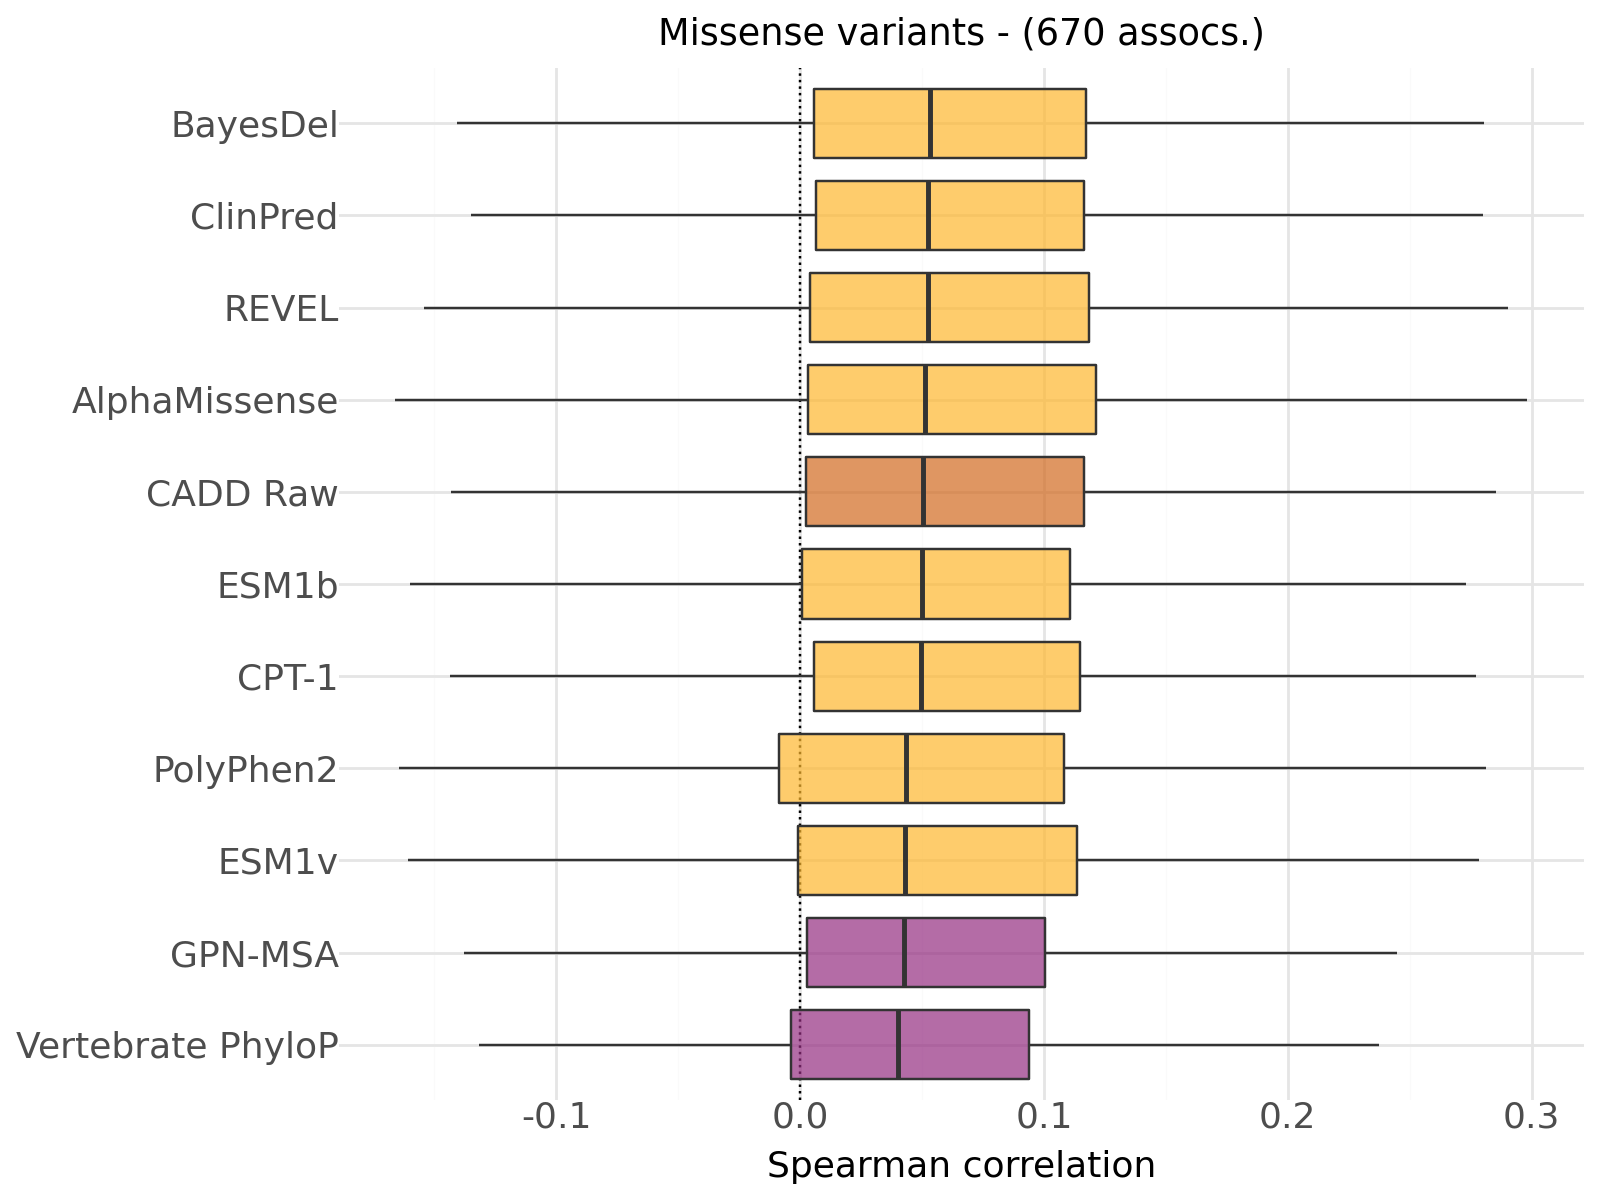

In [19]:
plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

if exclude_clinvar:
    plot_title = f"{vc['x_label']} (no ClinVar)"
elif only_clinvar:
    plot_title = f"{vc['x_label']} (only ClinVar)"
else:
    plot_title = vc['x_label']

# Calculate medians and join back
exclude_annos = ['promoterai_over', 'abexp_min', 'zooverphylop', 'zoopriphylop', 'priphylop', 'mamphylop', 'abexp_max']
plot_corr_pl = (
    filt_corr_df
    .drop_nans()
    .filter(~pl.col('annotation').is_in(exclude_annos))
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)


# 2. Determine the categorical order for the labels
ordered_labels = (
    plot_corr_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
plot_corr_pl = plot_corr_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

# 4. Create the color dictionary (Polars style)
color_dict = dict(plot_corr_pl.select("annotation", "color").unique().iter_rows())

# Plot
(
    ggplot(plot_corr_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    # + geom_boxplot(alpha=0.7)
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{plot_title} variants - ({gene_trait_df.shape[0]} assocs.)",
        # title=f"{plot_corr_pl[['region', 'phenotype']].unique().shape[0]} gene-trait assoc. - {vc['x_label']} variants"
    )
    + coord_flip()
    + theme(
        figure_size=(8, plot_corr_pl['annotation'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

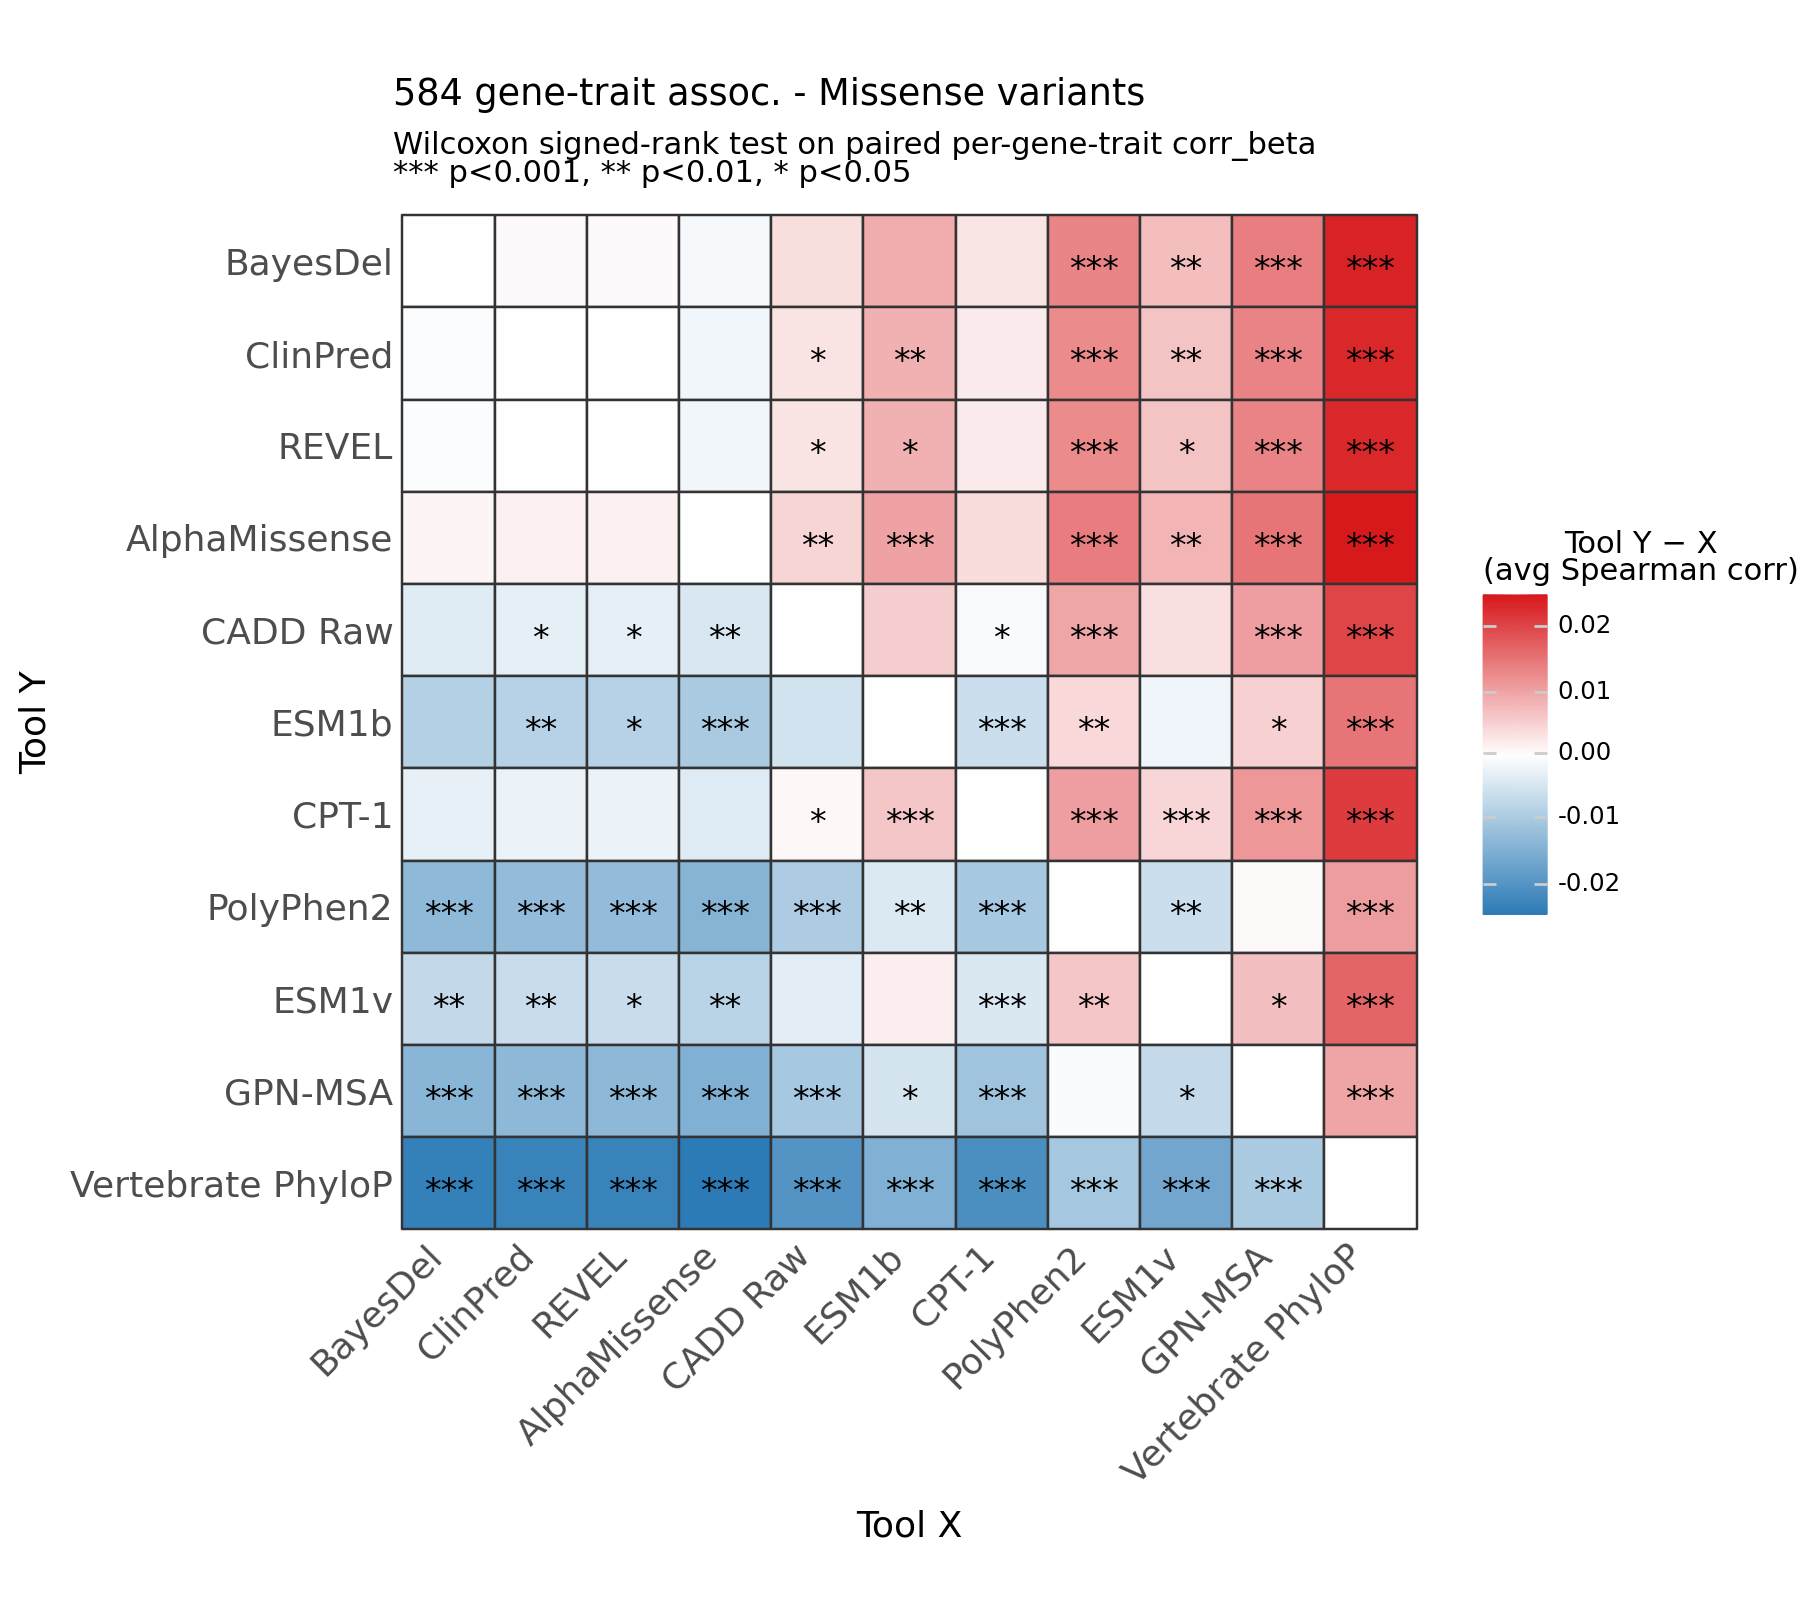

In [20]:
import pandas as pd
import itertools
import numpy as np
from scipy import stats

# --- 1. Determine annotation set and ordering ---
plot_annotations = plot_corr_pl.select("annotation").unique().to_series().to_list()


# Filter tools
plot_annotations = [a for a in plot_annotations if a not in exclude_annos]

# Build annotation -> label mapping
anno_to_label = dict(
    plot_corr_pl.select(["annotation", "label"]).unique().iter_rows()
)

# Order tools by median corr_beta (best first)
tool_medians = {}
for ann in plot_annotations:
    vals = plot_corr_pl.filter(pl.col("annotation") == ann)["corr_beta"].to_numpy()
    tool_medians[ann] = float(np.nanmedian(vals))

ordered_tools  = sorted(tool_medians.keys(), key=lambda x: tool_medians[x], reverse=True)
ordered_labels = [anno_to_label.get(t, t) for t in ordered_tools]

# --- 2. Pairwise Wilcoxon signed-rank test on paired (region, phenotype) corr_beta ---
heatmap_data = []

for ann_x, ann_y in itertools.product(ordered_tools, repeat=2):
    label_x = anno_to_label.get(ann_x, ann_x)
    label_y = anno_to_label.get(ann_y, ann_y)

    if ann_x == ann_y:
        heatmap_data.append({
            'Tool_X': label_x,
            'Tool_Y': label_y,
            'mean_diff': 0.0,
            'sig': ''
        })
        continue

    # Inner join on (region, phenotype) to get paired values
    df_x = plot_corr_pl.filter(pl.col("annotation") == ann_x).select(["region", "phenotype", "corr_beta"])
    df_y = plot_corr_pl.filter(pl.col("annotation") == ann_y).select(["region", "phenotype", "corr_beta"])

    paired = df_x.join(df_y, on=["region", "phenotype"], suffix="_y")
    c_x = paired["corr_beta"].to_numpy()
    c_y = paired["corr_beta_y"].to_numpy()

    mean_diff = float(c_y.mean() - c_x.mean())

    if len(c_x) >= 10 and not np.allclose(c_x, c_y):
        _, p_val = stats.wilcoxon(c_x, c_y, alternative='two-sided')
    else:
        p_val = 1.0

    if   p_val < 0.001: sig = '***'
    elif p_val < 0.01:  sig = '**'
    elif p_val < 0.05:  sig = '*'
    else:               sig = ''

    heatmap_data.append({
        'Tool_X': label_x,
        'Tool_Y': label_y,
        'mean_diff': mean_diff,
        'sig': sig
    })

df_heat = pd.DataFrame(heatmap_data)

# Lock in categorical order so best tools appear top/right
df_heat['Tool_X'] = pd.Categorical(df_heat['Tool_X'], categories=ordered_labels,       ordered=True)
df_heat['Tool_Y'] = pd.Categorical(df_heat['Tool_Y'], categories=ordered_labels[::-1], ordered=True)

n_tools = len(ordered_tools)

# --- 3. Plot ---
(
    ggplot(df_heat, aes(x='Tool_X', y='Tool_Y', fill='mean_diff'))
    + geom_tile(color="#333333", size=0.5)
    + geom_text(aes(label='sig'), color="black", size=12, va='center', nudge_y=-0.1)
    + scale_fill_gradient2(low="#2C7BB6", mid="#FFFFFF", high="#D7191C", midpoint=0)
    + labs(
        title=f"{plot_corr_pl[['region', 'phenotype']].unique().shape[0]} gene-trait assoc. - {vc['x_label']} variants",
        subtitle="Wilcoxon signed-rank test on paired per-gene-trait corr_beta\n*** p<0.001, ** p<0.01, * p<0.05",
        x="Tool X",
        y="Tool Y",
        fill="Tool Y \u2212 X\n(avg Spearman corr)"
    )
    + theme_minimal()
    + theme(
        figure_size=(n_tools * 0.6 + 2.5, n_tools * 0.6 + 1.5),
        aspect_ratio=1,
        axis_title=element_text(size=13),
        axis_text=element_text(size=13),
        axis_text_x=element_text(rotation=45, hjust=1),
        panel_grid=element_blank(),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [14]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_44695/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""clinpred_score""","""priphylop""",584,35753.0,4.3334e-34
"""clinpred_score""","""zoopriphylop""",584,36536.0,4.4707e-33
"""zooverphylop""","""cadd_raw""",584,36661.0,6.4672e-33
"""cadd_raw""","""priphylop""",584,37111.0,2.4242e-32
"""zoopriphylop""","""cadd_raw""",584,37593.0,9.8492e-32
…,…,…,…,…
"""esm1b_llr""","""gpn_score""",584,75717.0,0.017495
"""cadd_raw""","""revel_score""",584,75945.0,0.020327
"""clinpred_score""","""cadd_raw""",584,76068.0,0.022016


# Stratify by LOEUF score

In [15]:
gnom = (
    pl.read_csv(
        "/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv", 
        null_values=["NA"],
        separator='\t'
    )
    .filter(
        pl.col('transcript_type')=='protein_coding',
        pl.col('canonical')==True
        # pl.col('mane_select')==True
    )
    .select(['gene_id', 'lof.oe_ci.upper'])
    .rename({'gene_id': 'region', 'lof.oe_ci.upper': 'loeuf'})
    .drop_nulls()
)

gnom

region,loeuf
str,f64
"""ENSG00000121410""",1.34
"""ENSG00000148584""",0.825
"""ENSG00000175899""",0.765
"""ENSG00000166535""",0.953
"""ENSG00000184389""",1.529
…,…
"""ENSG00000288914""",1.87
"""ENSG00000289027""",0.885
"""ENSG00000289258""",0.982


In [16]:
set(correlation_df['region'].unique()) - set(gnom['region'].unique())

{'ENSG00000162600'}

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 19'. Pick better value with 'binwidth'.


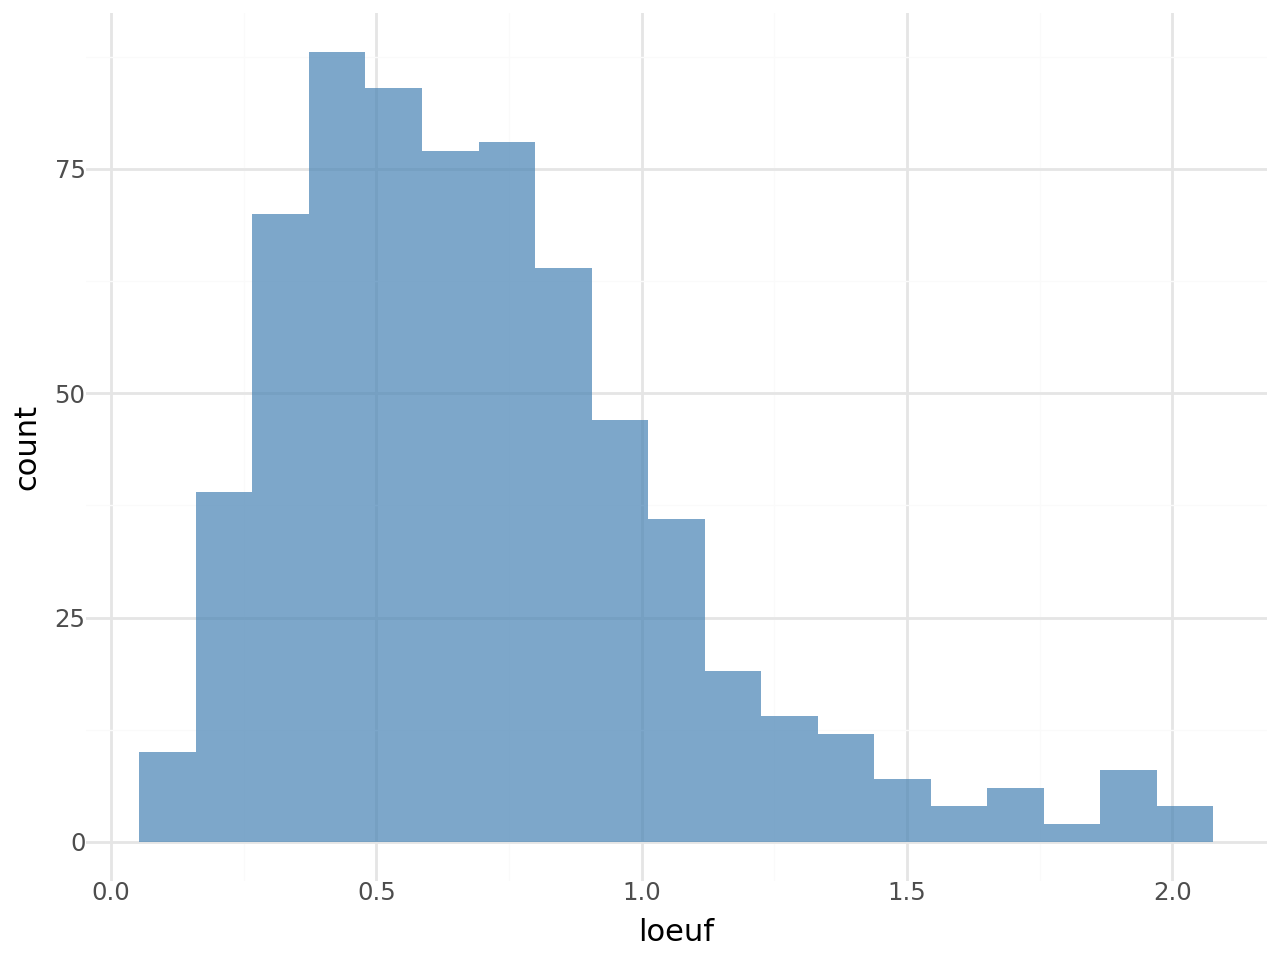

In [17]:
tmp = gnom.join(correlation_df.select(['region']).unique(), on='region', how='inner').with_columns(subset=pl.lit('ukbbgym_pheno'))

(
    ggplot(tmp, aes(x='loeuf'))
    + geom_histogram(position='identity', fill='steelblue', alpha=0.7)
    + theme_minimal()
)

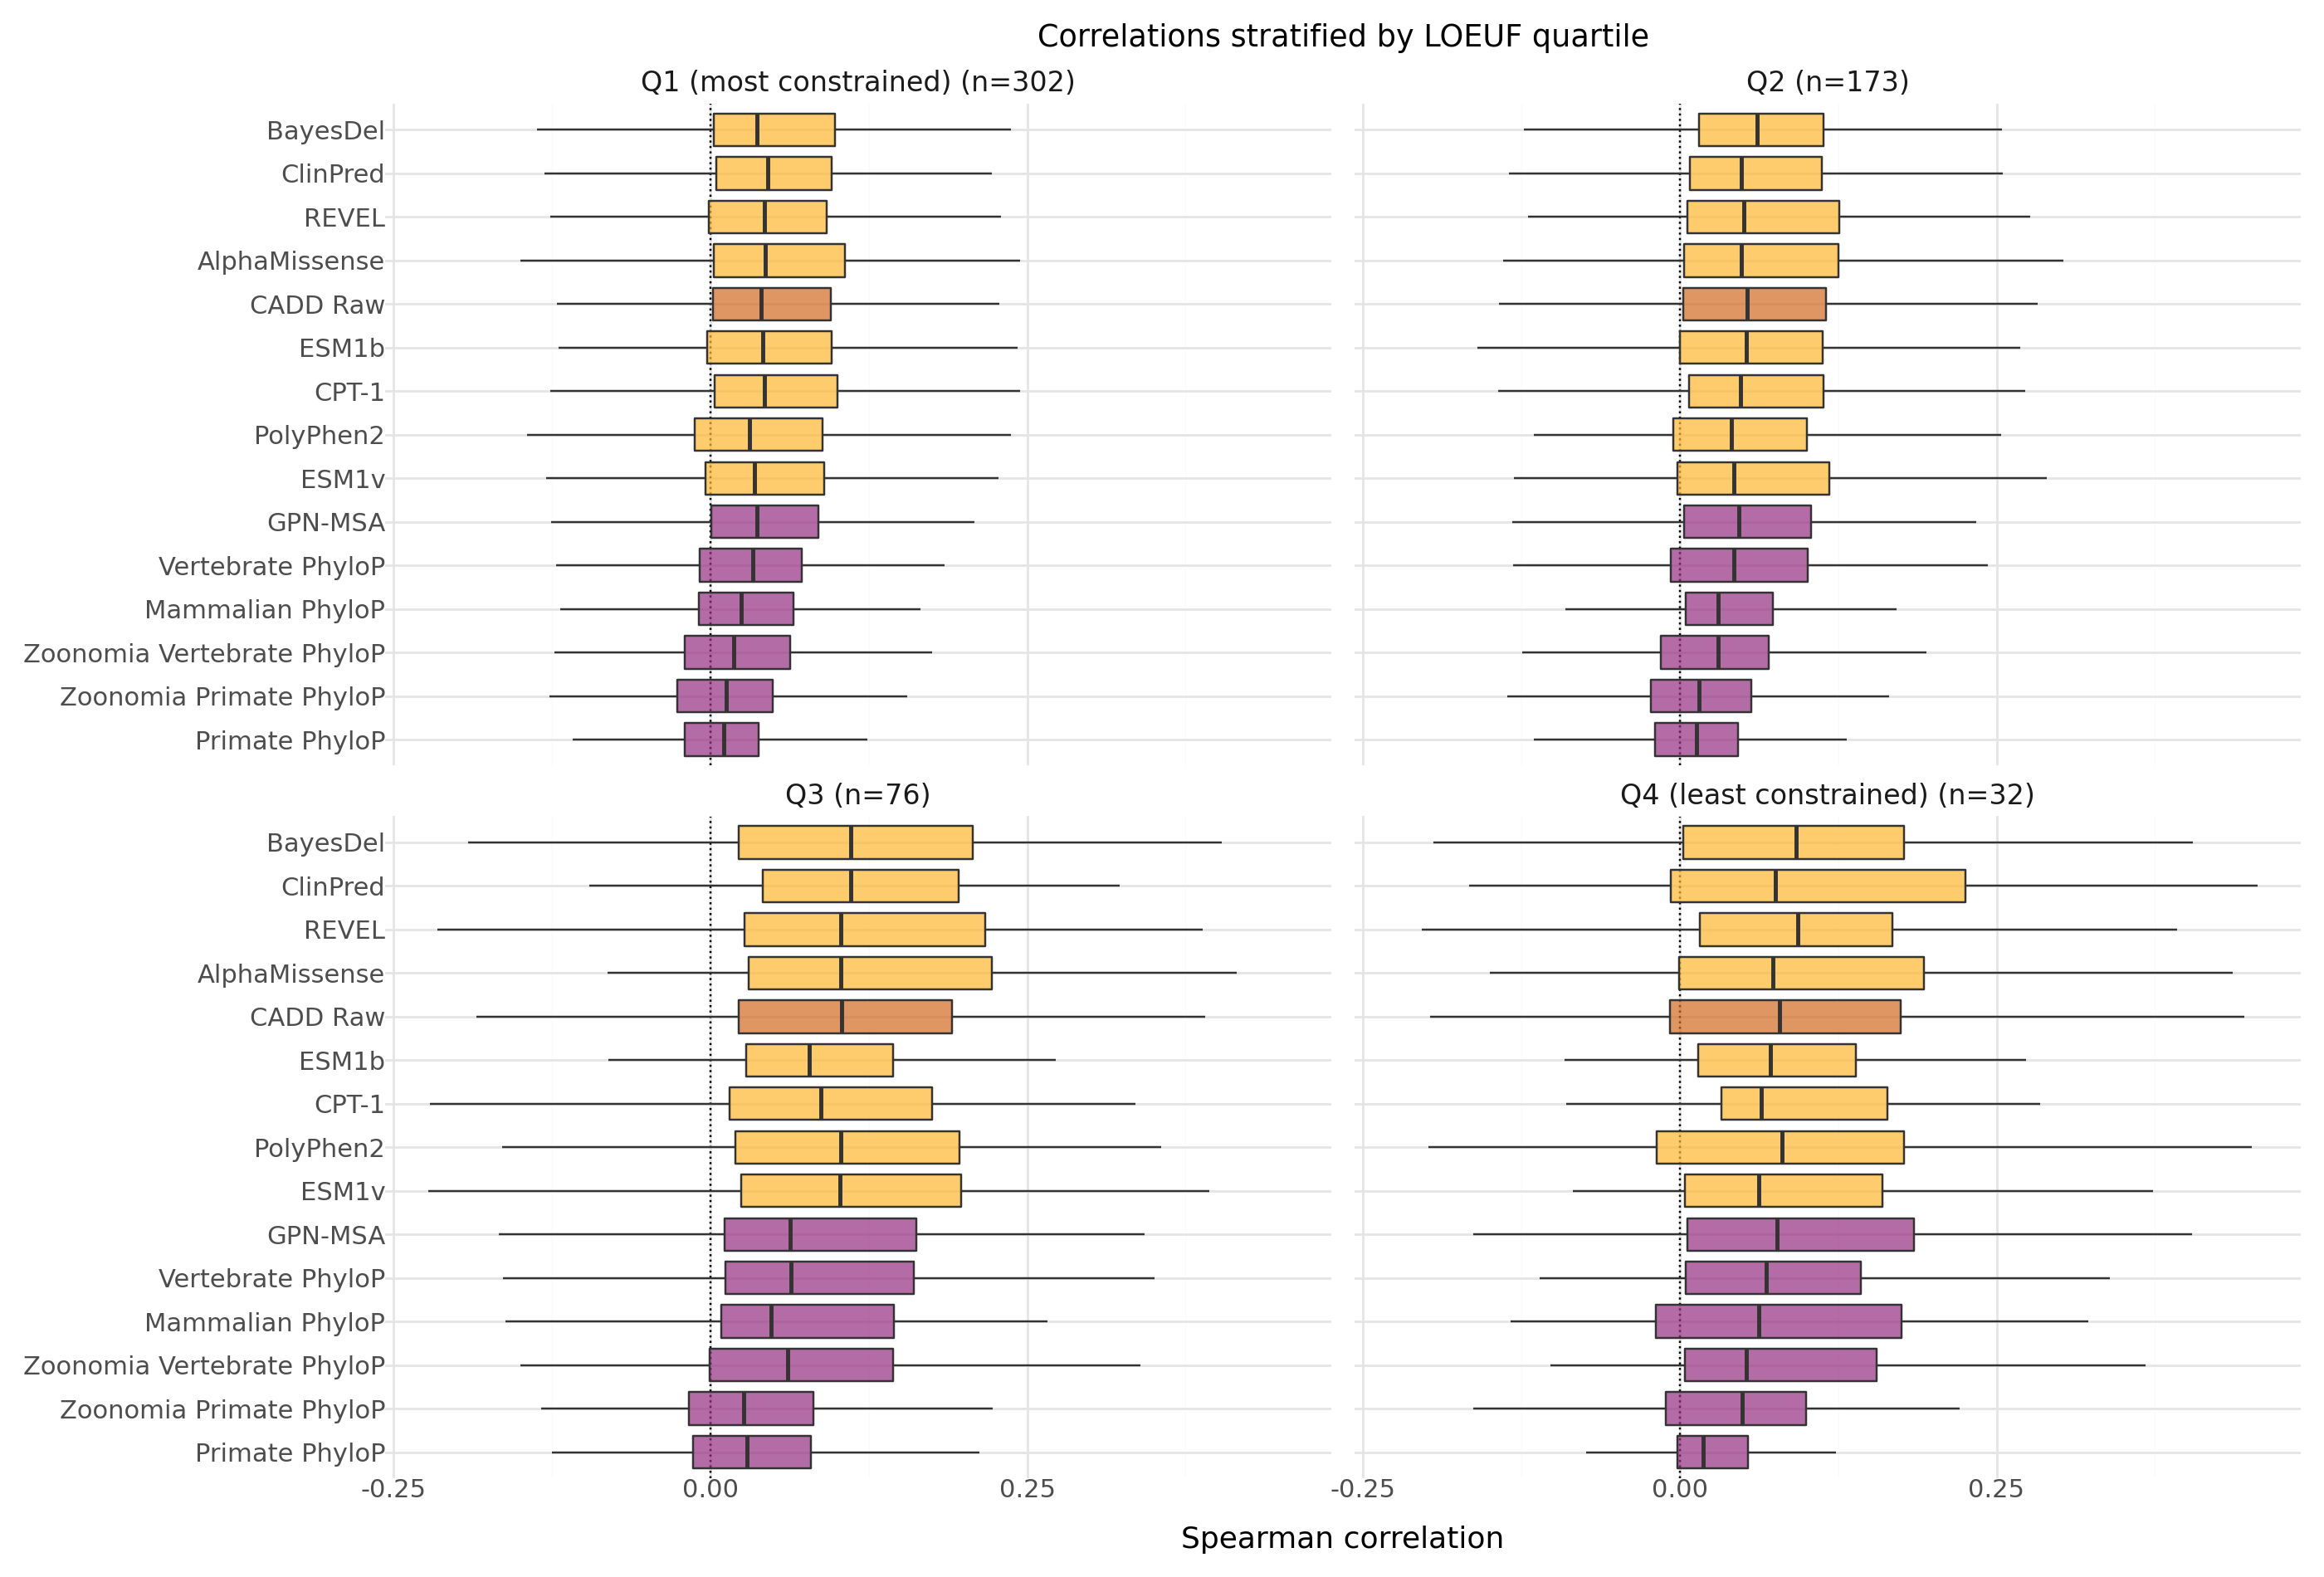

In [18]:
# Create 4 LOEUF bins from the full gnomAD constraint table
loeuf_bins = gnom.with_columns(
    loeuf_bin = pl.col('loeuf').qcut(4, labels=['Q1 (most constrained)', 'Q2', 'Q3', 'Q4 (least constrained)'])
)

# Join LOEUF bins to filt_corr_df
corr_loeuf = (
    filt_corr_df
    .join(loeuf_bins, on='region', how='inner')
    .drop_nans()
)

# Add n= counts to the bin labels
bin_counts = (
    corr_loeuf
    .select(['region', 'phenotype', 'loeuf_bin'])
    .unique(subset=['region', 'phenotype'])
    .group_by('loeuf_bin')
    .len()
)
bin_label_map = {
    row[0]: f"{row[0]} (n={row[1]})" for row in bin_counts.iter_rows()
}
corr_loeuf = corr_loeuf.with_columns(
    pl.col('loeuf_bin').cast(pl.Utf8).replace(bin_label_map).alias('loeuf_bin')
)

plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Order annotations by overall median
corr_loeuf_pl = corr_loeuf.with_columns(
    median_corr_beta = pl.col(plotting_col).median().over("annotation")
)

ordered_labels = (
    corr_loeuf_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

corr_loeuf_pl = corr_loeuf_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

color_dict = dict(corr_loeuf_pl.select("annotation", "color").unique().iter_rows())

(
    ggplot(corr_loeuf_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + facet_wrap("~loeuf_bin", ncol=2)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"Correlations stratified by LOEUF quartile"
    )
    + coord_flip()
    + theme(
        figure_size=(14, corr_loeuf_pl['annotation'].n_unique()/2 + 2),
        legend_position="none",
        axis_text=element_text(size=11),
        axis_title=element_text(size=13),
        strip_text=element_text(size=12),
        plot_background=element_rect(fill="white", color="white"),
    )
)